## **Preprocesamiento completo de datos de cartera**
Este notebook incluye limpieza, codificación, transformación, manejo de nulos y outliers.

### **Librerías**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from difflib import get_close_matches
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import joblib

### **Cargue de datos**

In [90]:
ruta_cierre = r"C:\Users\USER\OneDrive - universidadean.edu.co\2. Semestre\Seminario de investigación\Modulo 2\Modelo ML\data\raw\cierres_cartera_consolidado.xlsx"
df_cartera = pd.read_excel(ruta_cierre)

In [91]:
df=df_cartera.copy()
# Muestra todas las columnas
pd.set_option('display.max_columns', None)

# Opcional: también puedes ajustar el ancho máximo por columna si se corta el contenido
pd.set_option('display.max_colwidth', None)

# Ahora imprime tu DataFrame
df.head(5)


,NUMERO DE LA COLOCACION,NUMERO DE IDENTIFICACION DEUDOR,NUMERO DEL PRODUCTO,NUMERO DE LA AGENCIA,PLAZO UNIDAD TIEMPO,PLAZO EN DIAS,NUMERO DE PAGOS PACTA,UNIDAD DE TIEMPO,VALOR ORIGINAL DEL PR,CAPITAL PEND POR FACT,FECHA APERTURA DEL PR,SALDO DEL PRESTAMO,NRO PLAN PAGOS VIGENT,NRO DE UTILIZACINES D,DIAS DE MORA,CALIFICACION CARTERA,FEC CUOTA MAS ANTIG PENDIENTE DE PAGO,FEC PROX PAGO,FECHA EFEC ULTIMO PAGO,VLR ULTIMO PAGO,VLR TASA,VLR CUOTA MES,VLR MINIMO DE PAGO,DIA VENCIMIENTO CUOTA,NRO CUOTAS VENCIDAS,NRO CUOTAS PAGADAS,NRO CUOTAS RESTANTE,NIVEL DE ESTUDIOS,MARCA,TIPO DE SOLICITANTE,TIPO DE ID,OCUPACIÓN,ACIERTA,TIPO DE VIVIENDA,ANTIGÜEDAD LABORAL,ESTADO CIVIL,NUMERO DE PERSONAS A CARGO,INGRESOS,TIPO DE VEHICULO,TIPO DE SERVICIO,PRODUCTO,FECHA_CIERRE
0,90,52743777,905,223,72,2160,72,M,50000000,0.0,20170912,19879034.0,2,43.0,1551.0,IN,20191102.0,20210602,20191001.0,44606931.0,15.98540,102006,46184825.0,2,20.0,24,48.0,BACHILLERATO,KIA,INDEPENDIENTE,CEDULA,NO DEFINIDO,0,FAMILIAR,60,UNION LIBRE,0,6800000,NUEVO,PARTICULAR,CARTERA CASTIGADA,2024-01-31
1,148,80138994,905,222,60,1800,60,M,42850000,0.0,20171003,9995618.0,1,45.0,1172.0,IN,20201115.0,20210815,20201009.0,38415108.0,20.47944,510642,20618246.0,15,10.0,35,25.0,TECNOLOGICO,KIA,INDEPENDIENTE,CEDULA,COMERCIANTE,0,FAMILIAR,50,UNION LIBRE,0,7650000,NUEVO,PARTICULAR,CARTERA CASTIGADA,2024-01-31
2,185,1020770824,905,203,60,1800,60,M,33975000,0.0,20171031,32849398.0,1,59.0,2141.0,IN,20180322.0,20221022,20180802.0,2064553.0,25.06553,195106,85914638.0,22,56.0,3,57.0,PROFESIONAL,KIA,EMPLEADO,CEDULA,NO DEFINIDO,0,FAMILIAR,9,SOLTERO,0,3516860,NUEVO,PARTICULAR,CARTERA CASTIGADA,2024-01-31
3,189,1073671165,9,221,72,2160,72,M,31320000,0.0,20171031,3198913.0,3,44.0,14.0,AA,20240117.0,20240117,20231217.0,1700000.0,28.63795,3317850,3363836.0,17,1.0,71,1.0,BACHILLERATO,KIA,INDEPENDIENTE,CEDULA,PROFESIONAL INDEPENDIENTE,0,ARRENDADA,60,UNION LIBRE,2,5000000,NUEVO,PARTICULAR,VEHICULO CONSUMO,2024-01-31
4,199,1013601031,9,223,54,1620,51,M,53606700,8830472.8,20171103,10882092.8,6,40.0,14.0,B,20240117.0,20240217,20240130.0,2691030.0,23.54290,1421293,1433500.0,17,1.0,46,5.0,PROFESIONAL,KIA,EMPLEADO,CEDULA,NO DEFINIDO,0,FAMILIAR,48,SOLTERO,0,14800000,NUEVO,PARTICULAR,VEHICULO CONSUMO,2024-01-31


In [92]:
df.drop(columns=['UNIDAD DE TIEMPO','PLAZO UNIDAD TIEMPO','NUMERO DE LA AGENCIA'], inplace=True)

In [93]:
df.shape

(45011, 39)

| Producto                                | Descripción breve                                                              |
|-----------------------------------------|--------------------------------------------------------------------------------|
| CARTERA CASTIGADA                       | Créditos irrecuperables.                                                      |
| VEHICULO CONSUMO                        | Crédito para vehículo personal.                                               |
| VEHICULO COMERCIAL                      | Crédito para vehículo de uso comercial.                                       |
| POLIZA TODO RIESGO CASTIGO              | Seguro de vehículo asociado a crédito castigado.                              |
| PRESTAMOS SINIESTROS                    | Crédito vinculado a eventos con siniestros.                                   |
| VEHICULO CASTIGO                        | Crédito de vehículo que fue castigado.                                        |
| CALAMIDAD DOMESTICA CASTIGO            | Crédito por emergencia que fue castigado.                                     |
| CALAMIDAD DOMESTICA                     | Crédito para atender emergencias en el hogar.                                 |
| VEHICULO ALIVIO                         | Refinanciación de crédito vehicular.                                          |
| POLIZA TODO RIESGO                      | Seguro a todo riesgo vigente.                                                 |
| POLIZA ANT                              | Póliza anterior o vencida.                                                    |
| POSVENTA                                | Servicios posteriores a la venta.                                             |
| POLIZA MASCOTAS                         | Seguro para mascotas.                                                         |
| VEHICULO NOVACION                       | Reestructuración de crédito para vehículo.                                    |
| MOTO CASTIGO                            | Crédito para moto que fue castigado.                                          |
| RECUPERACION VEHICULO SIN CAUSACION     | Recuperación sin causa directa documentada.                                   |


In [94]:
"""# Estandarizar la columna PRODUCTO
df['PRODUCTO'] = df['PRODUCTO'].astype(str).str.upper().str.strip()

# Eliminar registros con productos asociados a mora
productos_en_mora = [
    'CARTERA CASTIGADA',
    'VEHICULO CASTIGO',
    'POLIZA TODO RIESGO CASTIGO',
    'PRESTAMOS SINIESTROS',
    'CALAMIDAD DOMESTICA CASTIGO',
    'MOTO CASTIGO',
    'RECUPERACION VEHICULO SIN CAUSACION'
]
df = df[~df['PRODUCTO'].isin(productos_en_mora)]

df.shape"""


"# Estandarizar la columna PRODUCTO\ndf['PRODUCTO'] = df['PRODUCTO'].astype(str).str.upper().str.strip()\n\n# Eliminar registros con productos asociados a mora\nproductos_en_mora = [\n    'CARTERA CASTIGADA',\n    'VEHICULO CASTIGO',\n    'POLIZA TODO RIESGO CASTIGO',\n    'PRESTAMOS SINIESTROS',\n    'CALAMIDAD DOMESTICA CASTIGO',\n    'MOTO CASTIGO',\n    'RECUPERACION VEHICULO SIN CAUSACION'\n]\ndf = df[~df['PRODUCTO'].isin(productos_en_mora)]\n\ndf.shape"

In [95]:
# Asegurar tipos y fechas correctas
df['NUMERO DEL PRODUCTO'] = pd.to_numeric(df['NUMERO DEL PRODUCTO'], errors='coerce')
df['FEC PROX PAGO'] = pd.to_datetime(df['FEC PROX PAGO'], format='%Y%m%d', errors='coerce')
df['FECHA EFEC ULTIMO PAGO'] = pd.to_datetime(df['FECHA EFEC ULTIMO PAGO'], format='%Y%m%d', errors='coerce')

# Lista de productos especiales
productos_especiales = [900, 901, 902, 903, 905, 906]

# Condición para aplicar la lógica
cond_producto = df['NUMERO DEL PRODUCTO'].isin(productos_especiales)
cond_mora_nula = df['DIAS DE MORA'].isna()
cond_cuotas_nulas = df['NRO CUOTAS VENCIDAS'].isna()
condicion_final = cond_producto & (cond_mora_nula | cond_cuotas_nulas)

# Calcular diferencia de fechas en días
diferencia_dias = (df['FEC PROX PAGO'] - df['FECHA EFEC ULTIMO PAGO']).dt.days

# Aplicar lógica
df.loc[condicion_final & diferencia_dias.notna(), 'DIAS DE MORA'] = diferencia_dias
df.loc[condicion_final & diferencia_dias.notna(), 'NRO CUOTAS VENCIDAS'] = 1  # o un valor razonable

# Rellenar el resto con 0 si aún hay nulos
df['DIAS DE MORA'] = df['DIAS DE MORA'].fillna(0)
df['NRO CUOTAS VENCIDAS'] = df['NRO CUOTAS VENCIDAS'].fillna(0)


In [96]:
# Reemplazar nulos con 0
df['DIAS DE MORA'] = pd.to_numeric(df['DIAS DE MORA'], errors='coerce').fillna(0)
df['NRO CUOTAS VENCIDAS'] = pd.to_numeric(df['NRO CUOTAS VENCIDAS'], errors='coerce').fillna(0)

In [97]:
df.shape

(45011, 39)

### **Creación de la etiqueta multicategoría**

Se genera una nueva variable que clasifica el comportamiento de cada crédito en función del cambio en su condición de mora en el mes siguiente. Para esto se usa la columna **`DIAS DE MORA`** como criterio principal.

---

#### Criterio para definir si un crédito está en mora:

- Un crédito se considera **"en mora"** si tiene **más de 30 días de mora** (`DIAS DE MORA > 30`).
- Caso contrario, se considera **"al día"**.

---

#### Clases definidas:

| Clase | Descripción            |
|-------|-------------------------|
| 0     | Se mantiene al día      |
| 1     | Entra en mora           |
| 2     | Sale de mora            |
| 3     | Se mantiene en mora     |

---

#### Lógica para transición entre meses:

- Se ordenan los datos por `NUMERO DE LA COLOCACION` y `FECHA_CIERRE`.
- Se compara el estado de mora del mes actual con el del mes siguiente, agrupando por crédito.
- Se genera la nueva columna `ESTADO_MORA_SIGUIENTE` con las 4 clases.





In [98]:
# Asegurarse que las fechas estén bien
df['FECHA_CIERRE'] = pd.to_datetime(df['FECHA_CIERRE'], errors='coerce')

# Ordenar el DataFrame por crédito y por fecha
df = df.sort_values(['NUMERO DE LA COLOCACION', 'FECHA_CIERRE'])

# Crear estado actual de mora: 1 si tiene más de 30 días de mora
df['MORA_ACTUAL'] = (df['DIAS DE MORA'] > 30).astype(int)

# Estado del mes siguiente usando shift(-1) por cada colocación
df['MORA_SIGUIENTE'] = df.groupby('NUMERO DE LA COLOCACION')['MORA_ACTUAL'].shift(-1)

# Crear función para clasificar transición
def clasificar_estado(actual, siguiente):
    if pd.isna(siguiente): return None
    if actual == 0 and siguiente == 0: return 0  # Se mantiene al día
    elif actual == 0 and siguiente == 1: return 1  # Entra en mora
    elif actual == 1 and siguiente == 0: return 2  # Sale de mora
    elif actual == 1 and siguiente == 1: return 3  # Se mantiene en mora

# Aplicar función fila por fila
df['ETIQUETA_MORA'] = [
    clasificar_estado(a, b) for a, b in zip(df['MORA_ACTUAL'], df['MORA_SIGUIENTE'])
]

# Eliminar filas sin valor en la etiqueta (últimos registros sin siguiente mes)
df = df.dropna(subset=['ETIQUETA_MORA'])
df['ETIQUETA_MORA'] = df['ETIQUETA_MORA'].astype(int)


In [99]:
df.shape

(40592, 42)

### **Normalizar columnas categóricas**

#### Normalizar con difflib

Verificar posibles incosistencias en variables categóricas

In [100]:
columnas = ['MARCA','NIVEL DE ESTUDIOS', 'TIPO DE SOLICITANTE', 'TIPO DE ID',
    'OCUPACIÓN', 'TIPO DE VIVIENDA', 'ESTADO CIVIL',
    'TIPO DE VEHICULO', 'TIPO DE SERVICIO', 'PRODUCTO']

print("Posibles categorías repetidas por similitud ortográfica:\n")

# Umbral de similitud: cuanto más bajo, más estricta es la detección
umbral = 0.85  # Puedes ajustar entre 0.7 - 0.95

for col in columnas:
    categorias = df[col].dropna().unique().tolist()
    categorias = sorted(set(map(str, categorias)))  # <- Conversión a str

    revisadas = set()
    sospechosas = []

    for cat in categorias:
        similares = get_close_matches(cat, categorias, n=5, cutoff=umbral)
        similares = [s for s in similares if s != cat and s not in revisadas]
        if similares:
            sospechosas.append((cat, similares))
            revisadas.update(similares)

    if sospechosas:
        print(f"{col}:")
        for base, similares in sospechosas:
            print(f"   - '{base}' ↔ {similares}")
    else:
        print(f"{col}: Sin posibles duplicados ortográficos detectados.")




Posibles categorías repetidas por similitud ortográfica:

MARCA:
   - '                     ' ↔ ['N                    ', 'SMW                  ', 'KIA                  ', 'JMC                  ']
   - 'AUDI                 ' ↔ ['SAIL                 ', 'SEAT                 ', 'MAZDA                ']
   - 'DFSK                 ' ↔ ['FUSO                 ']
   - 'DODGE                ' ↔ ['DOGE                 ', 'HONDA                ', 'GREAT                ', 'FORD                 ']
   - 'DOGE                 ' ↔ ['DODGE                ', 'YOYO                 ', 'JEEP                 ']
   - 'DONFENG              ' ↔ ['DONGFENG             ']
   - 'DONGFENG             ' ↔ ['DONFENG              ']
   - 'FIAT                 ' ↔ ['JKIA                 ']
   - 'FORD                 ' ↔ ['HINO                 ']
   - 'FOTON                ' ↔ ['VOLVO                ']
   - 'FUSO                 ' ↔ ['DFSK                 ']
   - 'GREAT                ' ↔ ['RENAULT              ', '

### Normalización manual

De acuerdo con la incosistencias encontradas se realiza la normalización de las variables categóricas

In [101]:
# Limpieza de variables categóricas

# Normalización general
df['MARCA'] = df['MARCA'].astype(str).str.strip().str.upper()
df['NIVEL DE ESTUDIOS'] = df['NIVEL DE ESTUDIOS'].astype(str).str.strip().str.upper()
df['TIPO DE SOLICITANTE'] = df['TIPO DE SOLICITANTE'].astype(str).str.strip().str.upper()
df['TIPO DE ID'] = df['TIPO DE ID'].astype(str).str.strip().str.upper()
df['OCUPACIÓN'] = df['OCUPACIÓN'].astype(str).str.strip().str.upper()
df['TIPO DE VIVIENDA'] = df['TIPO DE VIVIENDA'].astype(str).str.strip().str.upper()
df['ESTADO CIVIL'] = df['ESTADO CIVIL'].astype(str).str.strip().str.upper()
df['TIPO DE VEHICULO'] = df['TIPO DE VEHICULO'].astype(str).str.strip().str.upper()
df['TIPO DE SERVICIO'] = df['TIPO DE SERVICIO'].astype(str).str.strip().str.upper()
df['PRODUCTO'] = df['PRODUCTO'].astype(str).str.strip().str.upper()

# MARCA

reemplazos_marca = {
    'DOGE': 'DODGE',
    'DONFENG': 'DONGFENG',
    'MERCEDEZ BENZ': 'MERCEDES BENZ',
    'RENAUL': 'RENAULT',
    'REANULT': 'RENAULT',
    'PUEGEOT': 'PEUGEOT',
    'VOLKSVAGEN': 'VOLKSWAGEN',
    'VOLKWAGEN': 'VOLKSWAGEN',
    'VOLKSWAGENT': 'VOLKSWAGEN',
    'VOLKSWAGUEN': 'VOLKSWAGEN',
    'VOLSWAGEN': 'VOLKSWAGEN',
    'VOLSKWAGEN': 'VOLKSWAGEN',
    'WOLKSWAGEN': 'VOLKSWAGEN',
    'HYUNDAY': 'HYUNDAI',
    'NISSA': 'NISSAN',
    'ZUSUKI': 'SUZUKI',
    'JKIA': 'KIA',
    'YOYO': 'TOYOTA',
    'NO REGISTRADO': 'SIN INFORMACION',
    'N': 'SIN INFORMACION',
    'NINGUNA': 'SIN INFORMACION',
    '': 'SIN INFORMACION',
    'KIA RIO': 'KIA',
    'SUZUKI GRAND VITARA': 'SUZUKI',
    'TAXI GIRO': 'CHEVROLET',
    'SPORTAGE': 'KIA',
    'GREAT': 'GREAT WALL',
    'SAIL': 'CHEVROLET',
    'SANGYONG': 'SSANGYONG'
}
df['MARCA'] = df['MARCA'].replace(reemplazos_marca)


# NIVEL DE ESTUDIOS

df['NIVEL DE ESTUDIOS'] = df['NIVEL DE ESTUDIOS'].replace({
    'NO REGISTRADO': 'NO REGISTRA'
})


# TIPO DE SOLICITANTE

df['TIPO DE SOLICITANTE'] = df['TIPO DE SOLICITANTE'].replace({
    'NO REGISTRADO': 'SIN INFORMACION',
    'NO DEFINIDO': 'SIN INFORMACION',
    'TAXISTA ': 'TAXISTA'
})


# TIPO DE ID

df['TIPO DE ID'] = df['TIPO DE ID'].replace({
    'NO REGISTRADO': 'SIN INFORMACION',
    'ERROR DE REGISTRO': 'OTROS',
    'SOCIEDAD EXTRANJERA SIN NIT EN COLOMBIA': 'OTROS'
})


# OCUPACIÓN

df['OCUPACIÓN'] = df['OCUPACIÓN'].replace({
    'NO REGISTRADO': 'SIN INFORMACION',
    'NO DEFINIDO': 'SIN INFORMACION'
})


# TIPO DE VIVIENDA

df['TIPO DE VIVIENDA'] = df['TIPO DE VIVIENDA'].replace({
    'NO REGISTRA': 'SIN INFORMACION'
})


# ESTADO CIVIL

df['ESTADO CIVIL'] = df['ESTADO CIVIL'].replace({
    'NO REGISTRADO': 'SIN INFORMACION'
})


# TIPO DE VEHICULO

df['TIPO DE VEHICULO'] = df['TIPO DE VEHICULO'].replace({
    'OPERACIÓN ANULADA': 'SIN INFORMACION'
})


# TIPO DE SERVICIO

df['TIPO DE SERVICIO'] = df['TIPO DE SERVICIO'].replace({
    'OPERACIÓN ANULADA': 'SIN INFORMACION'
})


# NRO CUOTAS PAGADAS (corregir valores no numéricos)

df['NRO CUOTAS PAGADAS'] = pd.to_numeric(df['NRO CUOTAS PAGADAS'], errors='coerce')


#### Variables categoricas resultantes

In [102]:
cat_cols = df.select_dtypes(include='object').columns

# Mostrar categorías únicas por variable
for col in cat_cols:
    print(f"\n {col}")
    print(f"  - Total categorías únicas: {df[col].nunique()}")
    print(f"  - Categorías:\n    {df[col].unique()}")


 CALIFICACION CARTERA
  - Total categorías únicas: 9
  - Categorías:
    ['IN' 'A' 'B' 'C' 'AA' 'D' 'E' 'CC' 'BB' nan]

 NIVEL DE ESTUDIOS
  - Total categorías únicas: 9
  - Categorías:
    ['BACHILLERATO' 'TECNOLOGICO' 'PROFESIONAL' 'ESPECIALIZACION'
 'BASICA PRIMARIA' 'TECNICO' 'NO REGISTRA' 'TECNICO PROFESIONAL' 'MAESTRA']

 MARCA
  - Total categorías únicas: 40
  - Categorías:
    ['KIA' 'SIN INFORMACION' 'RENAULT' 'DODGE' 'VOLKSWAGEN' 'JAC' 'CHEVROLET'
 'NISSAN' 'PEUGEOT' 'SUZUKI' 'MAZDA' 'BMW' 'CITROEN' 'FORD' 'HONDA'
 'HYUNDAI' 'TOYOTA' 'SEAT' 'SSANGYONG' 'SUBARU' 'MITSUBISHI' 'FOTON' 'JMC'
 'FIAT' 'JETOUR' 'DONGFENG' 'KARRY' 'GREAT WALL' 'HINO' 'AUDI' 'SHINERAY'
 'FUSO' 'JEEP' 'DFSK' 'MERCEDES BENZ' 'VOLVO' 'KENWORTH' 'NO HAY'
 'CHANGAN' 'SMW']

 TIPO DE SOLICITANTE
  - Total categorías únicas: 5
  - Categorías:
    ['INDEPENDIENTE' 'EMPLEADO' 'TRANSPORTADOR' 'SIN INFORMACION' 'TAXISTA']

 TIPO DE ID
  - Total categorías únicas: 6
  - Categorías:
    ['CEDULA' 'SIN INFORMACION

### **Valores nulos**

In [103]:
# Calcular % de nulos
null_percent = df.isnull().mean() * 100
null_percent = null_percent[null_percent > 0].sort_values(ascending=False)

# Clasificar variables según el porcentaje de nulos
altos = null_percent[null_percent > 30]
moderados = null_percent[(null_percent > 5) & (null_percent <= 30)]
bajos = null_percent[(null_percent <= 5)]

# Mostrar los resultados
print("Variables con ALTO porcentaje de nulos (> 30%):\n")
print(altos.to_string(), "\n")

print("Variables con MODERADO porcentaje de nulos (5% - 30%):\n")
print(moderados.to_string(), "\n")

print("Variables con BAJO porcentaje de nulos (<= 5%):\n")
print(bajos.to_string())

Variables con ALTO porcentaje de nulos (> 30%):

Series([], ) 

Variables con MODERADO porcentaje de nulos (5% - 30%):

FECHA EFEC ULTIMO PAGO    5.365589 

Variables con BAJO porcentaje de nulos (<= 5%):

NRO CUOTAS PAGADAS                       4.914762
CALIFICACION CARTERA                     0.593713
FEC CUOTA MAS ANTIG PENDIENTE DE PAGO    0.219255
NRO DE UTILIZACINES D                    0.137958
NRO CUOTAS RESTANTE                      0.022172


#### Eliminar valores nulos con menor porcentaje

In [104]:
df.dropna(subset=['NRO DE UTILIZACINES D','FEC CUOTA MAS ANTIG PENDIENTE DE PAGO','NRO CUOTAS RESTANTE'], inplace=True)
df.shape

(40494, 42)

#### Imputación de valores nulos con mayor porcentaje basado en la moda 

In [105]:
# Calcular % de nulos
null_percent = df.isnull().mean() * 100
columns_with_nans = null_percent[null_percent > 0].index

# Imputar nulos por la moda (valor más frecuente)
for col in columns_with_nans:
    moda = df[col].mode(dropna=True)
    if not moda.empty:
        df[col].fillna(moda[0], inplace=True)
        print(f"Imputada columna '{col}' con la moda: {moda[0]}")
    else:
        print(f"No se pudo imputar '{col}' (columna vacía o sin moda)")

Imputada columna 'CALIFICACION CARTERA' con la moda: A
Imputada columna 'FECHA EFEC ULTIMO PAGO' con la moda: 2024-02-01 00:00:00
Imputada columna 'NRO CUOTAS PAGADAS' con la moda: 5.0


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_10668\1003977035.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(moda[0], inplace=True)
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_10668\1003977035.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

In [106]:
null_report = df.isnull().sum()
null_report = null_report[null_report > 0].sort_values(ascending=False)
print(f" Columnas con nulos:\n", null_report)

df.shape

 Columnas con nulos:
 Series([], dtype: int64)


(40494, 42)

### **Transformación de variables de fecha y derivadas**

In [107]:
# Fecha de referencia
hoy = pd.to_datetime('2024-01-31')

# Asegurar correcto formato de fechas (YYYYMMDD)
df['FECHA APERTURA DEL PR'] = pd.to_datetime(df['FECHA APERTURA DEL PR'], format='%Y%m%d', errors='coerce')
df['FEC PROX PAGO'] = pd.to_datetime(df['FEC PROX PAGO'], format='%Y%m%d', errors='coerce')
df['FECHA EFEC ULTIMO PAGO'] = pd.to_datetime(df['FECHA EFEC ULTIMO PAGO'], format='%Y%m%d', errors='coerce')
df['FEC CUOTA MAS ANTIG PENDIENTE DE PAGO'] = pd.to_datetime(df['FEC CUOTA MAS ANTIG PENDIENTE DE PAGO'], format='%Y%m%d', errors='coerce')

# Calcular variables de fechas
df['ANTIGUEDAD_CREDITO_MESES'] = (hoy - df['FECHA APERTURA DEL PR']).dt.days // 30
df['DIAS_HASTA_PROX_PAGO'] = (df['FEC PROX PAGO'] - hoy).dt.days
df['DIAS_DESDE_ULTIMO_PAGO'] = (hoy - df['FECHA EFEC ULTIMO PAGO']).dt.days
df['DIAS_CUOTA_PENDIENTE'] = (hoy - df['FEC CUOTA MAS ANTIG PENDIENTE DE PAGO']).dt.days


In [108]:
df.drop(columns=[
    'FECHA APERTURA DEL PR',
    'FEC PROX PAGO',
    'FECHA EFEC ULTIMO PAGO',
    'FEC CUOTA MAS ANTIG PENDIENTE DE PAGO',
], inplace=True)

In [109]:
df

,NUMERO DE LA COLOCACION,NUMERO DE IDENTIFICACION DEUDOR,NUMERO DEL PRODUCTO,PLAZO EN DIAS,NUMERO DE PAGOS PACTA,VALOR ORIGINAL DEL PR,CAPITAL PEND POR FACT,SALDO DEL PRESTAMO,NRO PLAN PAGOS VIGENT,NRO DE UTILIZACINES D,DIAS DE MORA,CALIFICACION CARTERA,VLR ULTIMO PAGO,VLR TASA,VLR CUOTA MES,VLR MINIMO DE PAGO,DIA VENCIMIENTO CUOTA,NRO CUOTAS VENCIDAS,NRO CUOTAS PAGADAS,NRO CUOTAS RESTANTE,NIVEL DE ESTUDIOS,MARCA,TIPO DE SOLICITANTE,TIPO DE ID,OCUPACIÓN,ACIERTA,TIPO DE VIVIENDA,ANTIGÜEDAD LABORAL,ESTADO CIVIL,NUMERO DE PERSONAS A CARGO,INGRESOS,TIPO DE VEHICULO,TIPO DE SERVICIO,PRODUCTO,FECHA_CIERRE,MORA_ACTUAL,MORA_SIGUIENTE,ETIQUETA_MORA,ANTIGUEDAD_CREDITO_MESES,DIAS_HASTA_PROX_PAGO,DIAS_DESDE_ULTIMO_PAGO,DIAS_CUOTA_PENDIENTE
0,90,52743777,905,2160,72,50000000,0.0,19879034.0,2,43.0,1551.0,IN,44606931.0,15.9854,102006,46184825.0,2,20.0,24.0,48.0,BACHILLERATO,KIA,INDEPENDIENTE,CEDULA,SIN INFORMACION,0,FAMILIAR,60,UNION LIBRE,0,6800000,NUEVO,PARTICULAR,CARTERA CASTIGADA,2024-01-31,1,1.0,3,77,-973,1583,1551
3088,90,52743777,905,2160,72,50000000,0.0,19879034.0,2,43.0,1579.0,IN,44606931.0,15.9854,102006,46718122.0,2,20.0,24.0,48.0,BACHILLERATO,KIA,INDEPENDIENTE,CEDULA,SIN INFORMACION,0,FAMILIAR,60,UNION LIBRE,0,6800000,NUEVO,PARTICULAR,CARTERA CASTIGADA,2024-02-28,1,1.0,3,77,-973,1583,1551
6196,90,52743777,905,2160,72,50000000,0.0,19879034.0,2,43.0,1611.0,IN,44606931.0,15.9854,102006,47301209.0,2,20.0,24.0,48.0,BACHILLERATO,KIA,INDEPENDIENTE,CEDULA,SIN INFORMACION,0,FAMILIAR,60,UNION LIBRE,0,6800000,NUEVO,PARTICULAR,CARTERA CASTIGADA,2024-03-30,1,1.0,3,77,-973,1583,1551
9291,90,52743777,905,2160,72,50000000,0.0,19879034.0,2,43.0,1640.0,IN,44606931.0,15.9854,102006,47823728.0,2,20.0,24.0,48.0,BACHILLERATO,KIA,INDEPENDIENTE,CEDULA,SIN INFORMACION,0,FAMILIAR,60,UNION LIBRE,0,6800000,NUEVO,PARTICULAR,CARTERA CASTIGADA,2024-04-29,1,1.0,3,77,-973,1583,1551
12330,90,52743777,905,2160,72,50000000,0.0,19879034.0,2,43.0,1671.0,IN,44606931.0,15.9854,102006,53951751.0,2,20.0,24.0,48.0,BACHILLERATO,KIA,INDEPENDIENTE,CEDULA,SIN INFORMACION,0,FAMILIAR,60,UNION LIBRE,0,6800000,NUEVO,PARTICULAR,CARTERA CASTIGADA,2024-05-30,1,1.0,3,77,-973,1583,1551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30342,8011001000020,79762099,905,1440,48,16110000,0.0,13357899.8,47,1.0,2309.0,IN,544300.0,20.3546,507810,47545813.0,6,35.0,12.0,36.0,NO REGISTRA,SIN INFORMACION,SIN INFORMACION,SIN INFORMACION,SIN INFORMACION,0,SIN INFORMACION,0,SIN INFORMACION,0,0,OTRO,OTRO,CARTERA CASTIGADA,2024-10-31,1,1.0,3,81,-1000,2065,2035
33230,8011001000020,79762099,905,1440,48,16110000,0.0,13357899.8,47,1.0,2339.0,IN,544300.0,20.3546,507810,47982380.0,6,35.0,12.0,36.0,NO REGISTRA,SIN INFORMACION,SIN INFORMACION,SIN INFORMACION,SIN INFORMACION,0,SIN INFORMACION,0,SIN INFORMACION,0,0,OTRO,OTRO,CARTERA CASTIGADA,2024-11-30,1,1.0,3,81,-1000,2065,2035
36178,8011001000020,79762099,905,1440,48,16110000,0.0,13357899.8,47,1.0,2370.0,E,544300.0,20.3546,507810,48394689.0,6,35.0,12.0,36.0,NO REGISTRA,SIN INFORMACION,SIN INFORMACION,SIN INFORMACION,SIN INFORMACION,0,SIN INFORMACION,0,SIN INFORMACION,0,0,OTRO,OTRO,CARTERA CASTIGADA,2024-12-31,1,1.0,3,81,-1000,2065,2035
39106,8011001000020,79762099,905,1440,48,16110000,0.0,13357899.8,47,1.0,2400.0,E,544300.0,20.3546,507810,48758390.0,6,35.0,12.0,36.0,NO REGISTRA,SIN INFORMACION,SIN INFORMACION,SIN INFORMACION,SIN INFORMACION,0,SIN INFORMACION,0,SIN INFORMACION,0,0,OTRO,OTRO,CARTERA CASTIGADA,2025-01-30,1,1.0,3,81,-1000,2065,2035


In [110]:
# Detectar posibles categóricas numéricas
posibles_cat_num = [col for col in df.select_dtypes(include=['int64', 'float64']).columns
                    if df[col].nunique() < 20]

# Mostrar resumen
for col in posibles_cat_num:
    print(f"\n {col}")
    print(f"  - Total categorías únicas: {df[col].nunique()}")
    print(f"  - Categorías:\n    {df[col].unique()}")


 NUMERO DEL PRODUCTO
  - Total categorías únicas: 18
  - Categorías:
    [905   9   1   2 902 700 900  15 903   5  11   4   8  10  13  14 906 901]

 NUMERO DE PERSONAS A CARGO
  - Total categorías únicas: 9
  - Categorías:
    [ 0  2  1  3  4 24  7 60 17]

 MORA_SIGUIENTE
  - Total categorías únicas: 2
  - Categorías:
    [1. 0.]


### **outliers**


In [111]:
# Variables monetarias: aplicar log(1 + x) para reducir asimetría
log_vars = ['INGRESOS', 'VALOR ORIGINAL DEL PR', 'VLR MINIMO DE PAGO']
for col in log_vars:
    if col in df.columns:
        df[col] = np.log1p(df[col].clip(lower=0))  # Evita log de valores negativos

# Variables con outliers moderados: recorte por IQR
iqr_vars = [
    'DIAS DE MORA',
    'NUMERO DE PERSONAS A CARGO',
    'ANTIGÜEDAD LABORAL',
    'NRO CUOTAS RESTANTE',
    'ANTIGUEDAD_CREDITO_MESES',
    'NUMERO DE PAGOS PACTA'
]
for col in iqr_vars:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - 3 * IQR
        lim_sup = Q3 + 3 * IQR
        df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)

# Variables con outliers severos (fechas acumuladas): recorte manual
clip_fijo = {
    'DIAS_HASTA_PROX_PAGO': (-365, 365),
    'DIAS_DESDE_ULTIMO_PAGO': (0, 730),
    'DIAS_CUOTA_PENDIENTE': (0, 730)
}
for col, (low, high) in clip_fijo.items():
    if col in df.columns:
        df[col] = df[col].clip(lower=low, upper=high)

print("Tratamiento de variables numéricas completado.")

Tratamiento de variables numéricas completado.


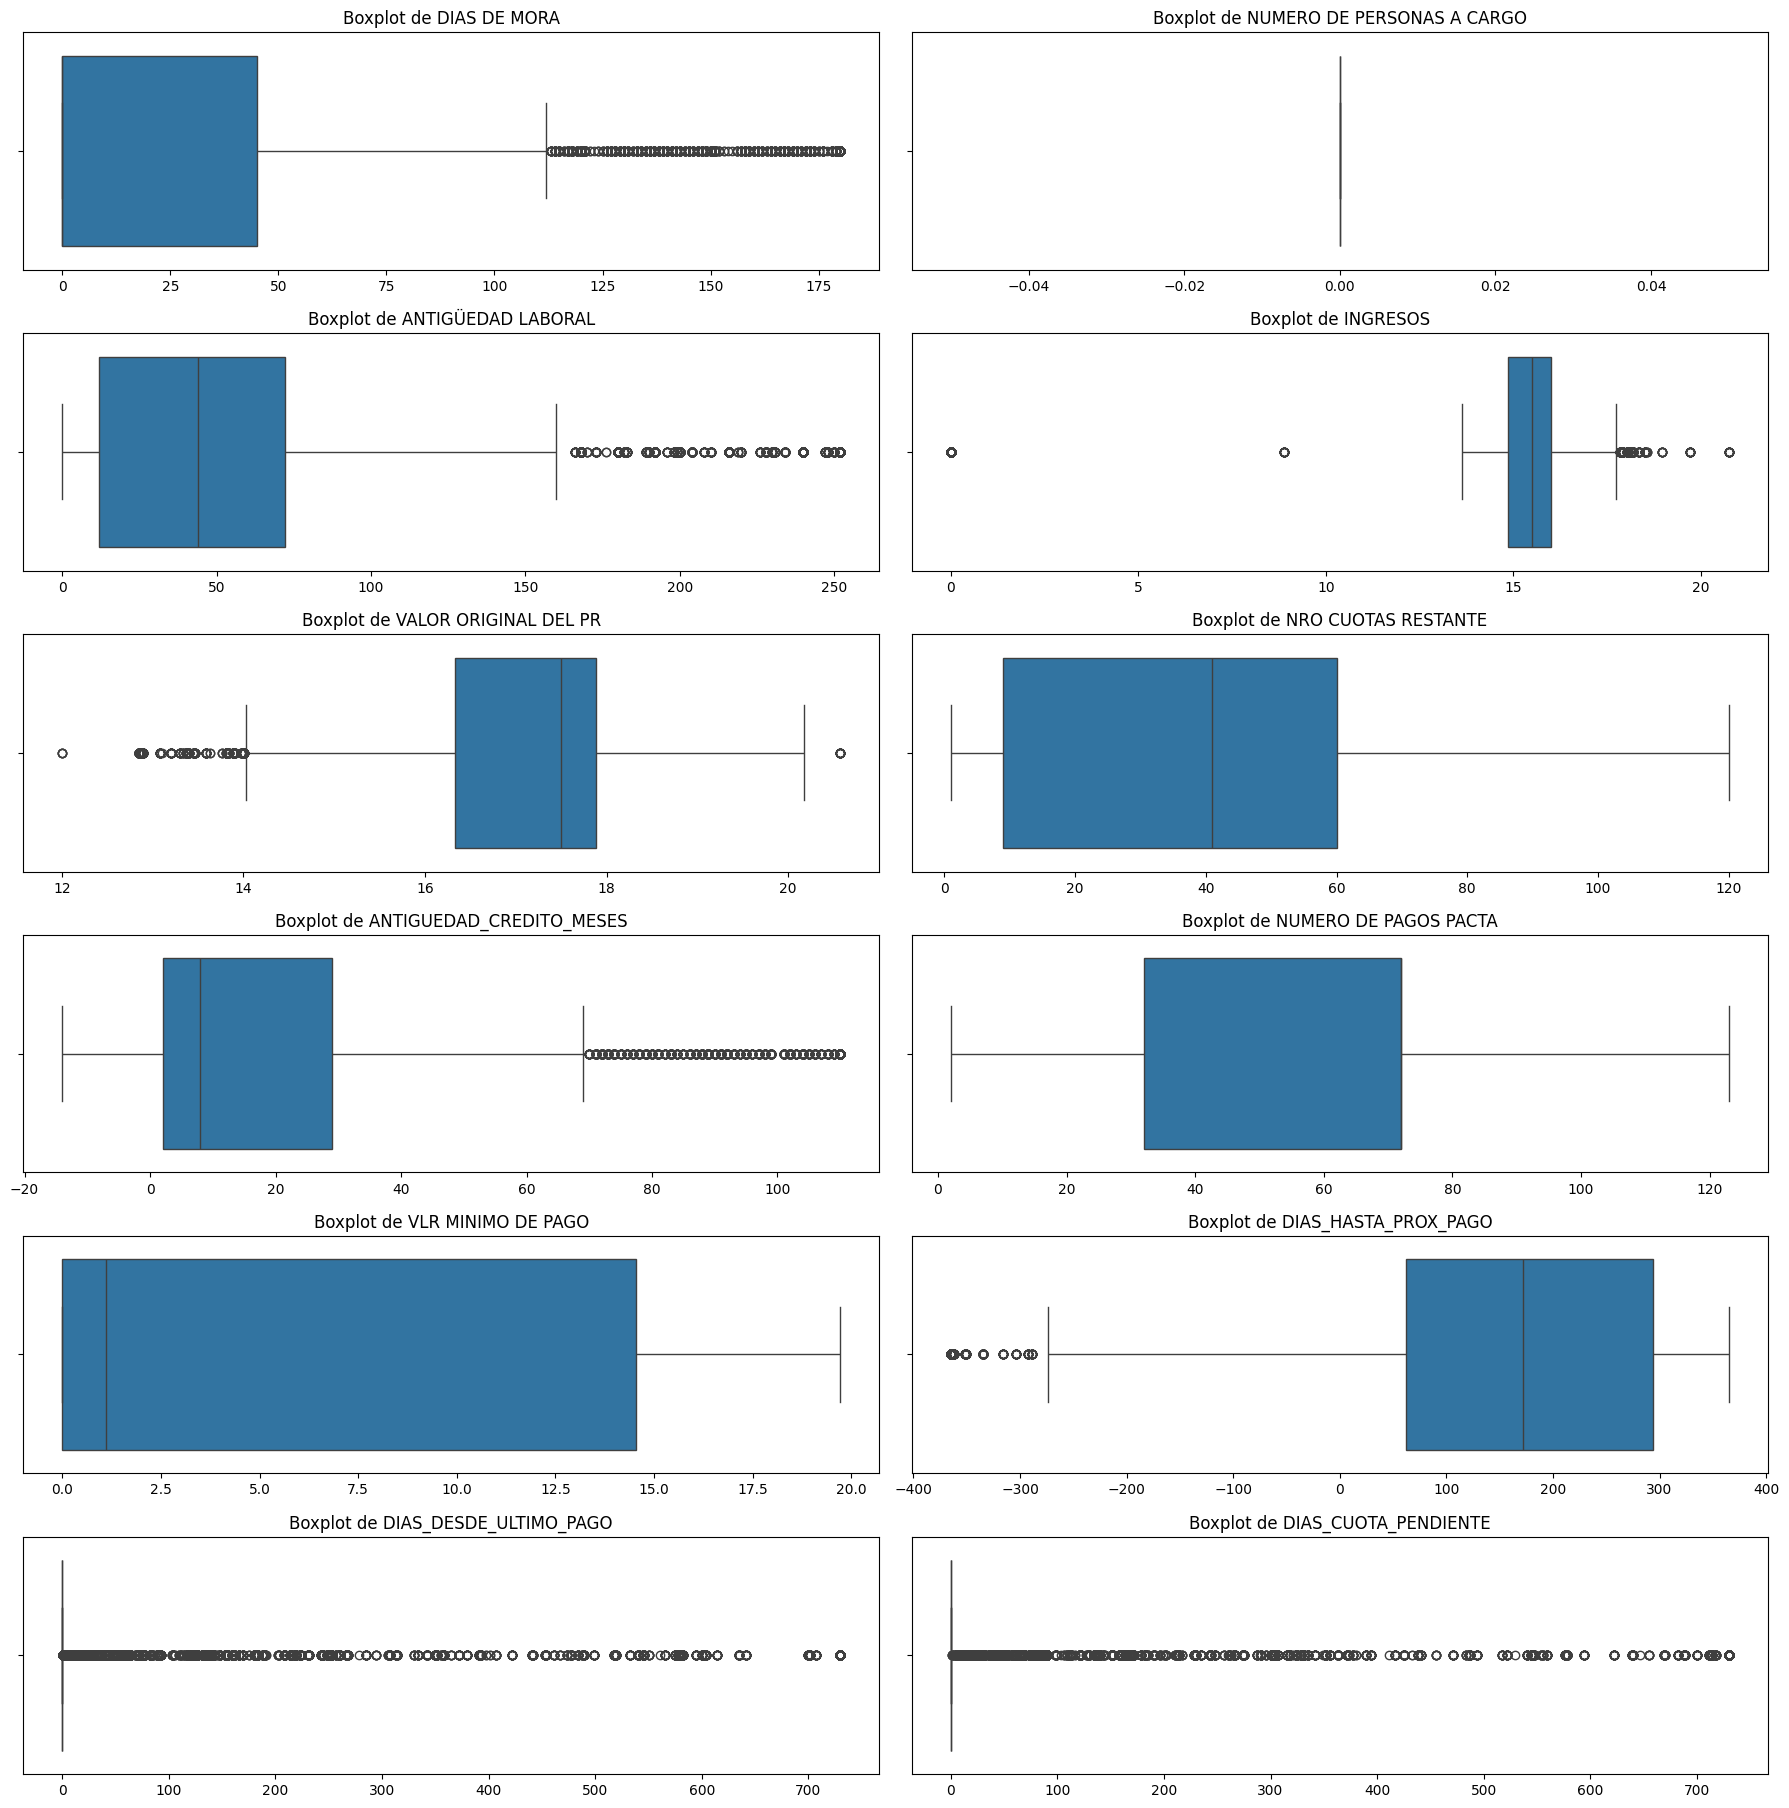

In [112]:
# Lista final de variables numéricas tratadas
variables_numericas = [
    'DIAS DE MORA',
    'NUMERO DE PERSONAS A CARGO',
    'ANTIGÜEDAD LABORAL',
    'INGRESOS',
    'VALOR ORIGINAL DEL PR',
    'NRO CUOTAS RESTANTE',
    'ANTIGUEDAD_CREDITO_MESES',
    'NUMERO DE PAGOS PACTA',
    'VLR MINIMO DE PAGO',
    'DIAS_HASTA_PROX_PAGO',
    'DIAS_DESDE_ULTIMO_PAGO',
    'DIAS_CUOTA_PENDIENTE'
]

# Filtrar variables que realmente existan en el DataFrame
variables_graficables = [col for col in variables_numericas if col in df.columns]

# Graficar boxplots
plt.figure(figsize=(18, 3 * len(variables_graficables)))

for i, col in enumerate(variables_graficables):
    plt.subplot(len(variables_graficables), 2, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

### **Codificación variables categoricas**



In [113]:
# VARIABLES CATEGÓRICAS
cat_cols_grandes = [
    'NUMERO DEL PRODUCTO', 'CALIFICACION CARTERA', 'NIVEL DE ESTUDIOS',
    'MARCA', 'PRODUCTO'
]

cat_cols_pequenas = [
    'TIPO DE SOLICITANTE', 'TIPO DE ID', 'OCUPACIÓN',
    'TIPO DE VIVIENDA', 'ESTADO CIVIL', 'TIPO DE VEHICULO', 'TIPO DE SERVICIO'
]

# 1. Codificar variables grandes con LabelEncoder (para usar embeddings)
label_encoders = {}
for col in cat_cols_grandes:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le  # Guarda para reutilizar en test o producción

# 2. Codificar variables pequeñas con One-Hot Encoding
df = pd.get_dummies(df, columns=cat_cols_pequenas, drop_first=True)

print(" Codificación completada. Dataset listo para escalar y crear secuencias.")




 Codificación completada. Dataset listo para escalar y crear secuencias.


In [114]:
df

,NUMERO DE LA COLOCACION,NUMERO DE IDENTIFICACION DEUDOR,NUMERO DEL PRODUCTO,PLAZO EN DIAS,NUMERO DE PAGOS PACTA,VALOR ORIGINAL DEL PR,CAPITAL PEND POR FACT,SALDO DEL PRESTAMO,NRO PLAN PAGOS VIGENT,NRO DE UTILIZACINES D,DIAS DE MORA,CALIFICACION CARTERA,VLR ULTIMO PAGO,VLR TASA,VLR CUOTA MES,VLR MINIMO DE PAGO,DIA VENCIMIENTO CUOTA,NRO CUOTAS VENCIDAS,NRO CUOTAS PAGADAS,NRO CUOTAS RESTANTE,NIVEL DE ESTUDIOS,MARCA,ACIERTA,ANTIGÜEDAD LABORAL,NUMERO DE PERSONAS A CARGO,INGRESOS,PRODUCTO,FECHA_CIERRE,MORA_ACTUAL,MORA_SIGUIENTE,ETIQUETA_MORA,ANTIGUEDAD_CREDITO_MESES,DIAS_HASTA_PROX_PAGO,DIAS_DESDE_ULTIMO_PAGO,DIAS_CUOTA_PENDIENTE,TIPO DE SOLICITANTE_INDEPENDIENTE,TIPO DE SOLICITANTE_SIN INFORMACION,TIPO DE SOLICITANTE_TAXISTA,TIPO DE SOLICITANTE_TRANSPORTADOR,TIPO DE ID_CEDULA,TIPO DE ID_CEDULA DE EXTRANJERIA,TIPO DE ID_NIT,TIPO DE ID_OTROS,TIPO DE ID_SIN INFORMACION,OCUPACIÓN_COMERCIANTE,OCUPACIÓN_OTRO,OCUPACIÓN_PROFESIONAL INDEPENDIENTE,OCUPACIÓN_RENTISTA DE CAPITAL,OCUPACIÓN_SIN INFORMACION,TIPO DE VIVIENDA_FAMILIAR,TIPO DE VIVIENDA_PROPIA,TIPO DE VIVIENDA_SIN INFORMACION,ESTADO CIVIL_DIVORCIADO,ESTADO CIVIL_RELIGIOSO,ESTADO CIVIL_SEPARADO,ESTADO CIVIL_SIN INFORMACION,ESTADO CIVIL_SOLTERO,ESTADO CIVIL_UNION LIBRE,ESTADO CIVIL_VIUDO,TIPO DE VEHICULO_OTRO,TIPO DE VEHICULO_SIN INFORMACION,TIPO DE VEHICULO_USADO,TIPO DE SERVICIO_PARTICULAR,TIPO DE SERVICIO_PUBLICO,TIPO DE SERVICIO_SIN INFORMACION
0,90,52743777,16,2160,72,17.727534,0.0,19879034.0,2,43.0,180.0,8,44606931.0,15.9854,102006,17.648162,2,20.0,24.0,48.0,0,22,0,60,0,15.732433,2,2024-01-31,1,1.0,3,77,-365,730,730,True,False,False,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
3088,90,52743777,16,2160,72,17.727534,0.0,19879034.0,2,43.0,180.0,8,44606931.0,15.9854,102006,17.659643,2,20.0,24.0,48.0,0,22,0,60,0,15.732433,2,2024-02-28,1,1.0,3,77,-365,730,730,True,False,False,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
6196,90,52743777,16,2160,72,17.727534,0.0,19879034.0,2,43.0,180.0,8,44606931.0,15.9854,102006,17.672046,2,20.0,24.0,48.0,0,22,0,60,0,15.732433,2,2024-03-30,1,1.0,3,77,-365,730,730,True,False,False,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
9291,90,52743777,16,2160,72,17.727534,0.0,19879034.0,2,43.0,180.0,8,44606931.0,15.9854,102006,17.683032,2,20.0,24.0,48.0,0,22,0,60,0,15.732433,2,2024-04-29,1,1.0,3,77,-365,730,730,True,False,False,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
12330,90,52743777,16,2160,72,17.727534,0.0,19879034.0,2,43.0,180.0,8,44606931.0,15.9854,102006,17.803601,2,20.0,24.0,48.0,0,22,0,60,0,15.732433,2,2024-05-30,1,1.0,3,77,-365,730,730,True,False,False,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30342,8011001000020,79762099,16,1440,48,16.594951,0.0,13357899.8,47,1.0,180.0,8,544300.0,20.3546,507810,17.677204,6,35.0,12.0,36.0,4,32,0,0,0,0.000000,2,2024-10-31,1,1.0,3,81,-365,730,730,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False
33230,8011001000020,79762099,16,1440,48,16.594951,0.0,13357899.8,47,1.0,180.0,8,544300.0,20.3546,507810,17.686344,6,35.0,12.0,36.0,4,32,0,0,0,0.000000,2,2024-11-30,1,1.0,3,81,-365,730,730,Fals

### **Escalar variables numericas**

In [ ]:
# Lista de variables numéricas a escalar (asegúrate que todas estén en el DataFrame)
variables_numericas = [
    'DIAS DE MORA',
    'NUMERO DE PERSONAS A CARGO',
    'ANTIGÜEDAD LABORAL',
    'INGRESOS',
    'VALOR ORIGINAL DEL PR',
    'NRO CUOTAS RESTANTE',
    'ANTIGUEDAD_CREDITO_MESES',
    'NUMERO DE PAGOS PACTA',
    'VLR MINIMO DE PAGO',
    'DIAS_HASTA_PROX_PAGO',
    'DIAS_DESDE_ULTIMO_PAGO',
    'DIAS_CUOTA_PENDIENTE'
]

# Instanciar el escalador
scaler = MinMaxScaler()

# Aplicar el escalado solo a las columnas que existen en df
vars_existentes = [col for col in variables_numericas if col in df.columns]
df[vars_existentes] = scaler.fit_transform(df[vars_existentes])

print(" Escalado con MinMaxScaler completado.")

In [ ]:
joblib.dump(scaler, 'scaler_lstm.pkl')  # Guarda el scaler

In [115]:
conteo_meses = df.groupby('NUMERO DE LA COLOCACION').size()
conteo_meses.describe()

count    4177.000000
mean        9.694518
std         4.681376
min         1.000000
25%         5.000000
50%        12.000000
75%        14.000000
max        14.000000
dtype: float64

In [116]:
# Ruta donde se guardará el archivo
ruta_csv_completo = r"C:\Users\USER\OneDrive - universidadean.edu.co\2. Semestre\Seminario de investigación\Modulo 2\Modelo ML\data\processed\df_preprocesado_LSTM.csv"

# Guardar como CSV
df.to_csv(ruta_csv_completo, index=False)

print(f" Dataset completo guardado como CSV en:\n{ruta_csv_completo}")


 Dataset completo guardado como CSV en:
C:\Users\USER\OneDrive - universidadean.edu.co\2. Semestre\Seminario de investigación\Modulo 2\Modelo ML\data\processed\df_preprocesado_LSTM.csv
